<a href="https://colab.research.google.com/github/acrissguimaraes/my-lab/blob/main/HR_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IBM HR Analytics: A Data-Driven Study on Employee Attrition and Performance

Dataset: IBM HR Analytics Employee Attrition & Performance

Core Topic: Employee Attrition


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Business Understanding

*  Who leaves the most?
*  Does income influence attrition?
*  Does tenure matter?

Data understanding

In [ ]:
df = pd.read_csv('/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
print(df.shape)
print(df.columns.tolist())

(1470, 35)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


Data Preparation

In [ ]:
df['Attrition_bin'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['YearsRange'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0, 2, 5, 10, 40],
    labels=['0-2 years', '3-5 years', '6-10 years', '11+ years'],
    include_lowest=True
)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_bin,YearsRange
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,8,0,1,6,4,0,5,1,6-10 years
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,1,10,3,3,10,7,1,7,0,6-10 years
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,7,3,3,0,0,0,0,1,0-2 years
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,0,8,3,3,8,7,3,0,0,6-10 years
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,1,6,3,3,2,2,2,2,0,0-2 years


In [ ]:
df['Income_Range'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 5000, 10000, 15000, 25000],
    labels=['Low (0-5k)', 'Medium (5k-10k)', 'High (10k-15k)', 'Executive (15k+)'],
    include_lowest=True
)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_bin,YearsRange,Tenure_Range,Income_Range
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,1,6-10 years,6-10 years,Medium (5k-10k)
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,0,6-10 years,6-10 years,Medium (5k-10k)
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,1,0-2 years,0-2 years,Low (0-5k)
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,0,6-10 years,6-10 years,Low (0-5k)
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,0,0-2 years,0-2 years,Low (0-5k)


Data Visualization & Insights

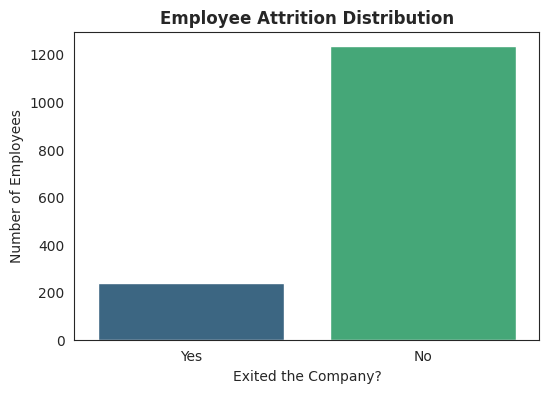

In [ ]:
plt.figure(figsize=(6, 4))
sns.set_style("white")
sns.countplot(data=df,  x="Attrition", palette="viridis", hue="Attrition", legend=False)
plt.title("Employee Attrition Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Exited the Company?", fontsize=10)
plt.ylabel("Number of Employees", fontsize=10)
plt.show()

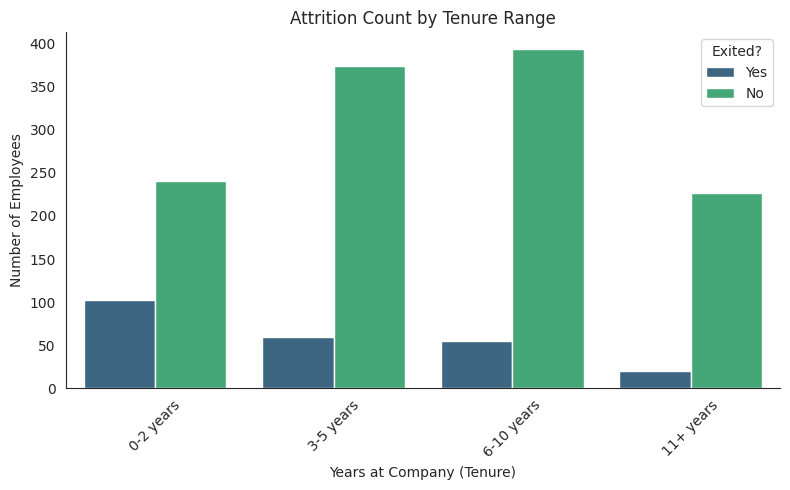

In [ ]:
plt.figure(figsize=(8, 5))
sns.set_style("white")

sns.countplot(data=df, x="YearsRange", hue="Attrition", palette="viridis")
plt.title("Attrition Count by Tenure Range")
plt.xlabel("Years at Company (Tenure)")
plt.ylabel("Number of Employees")
plt.legend(title="Exited?")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

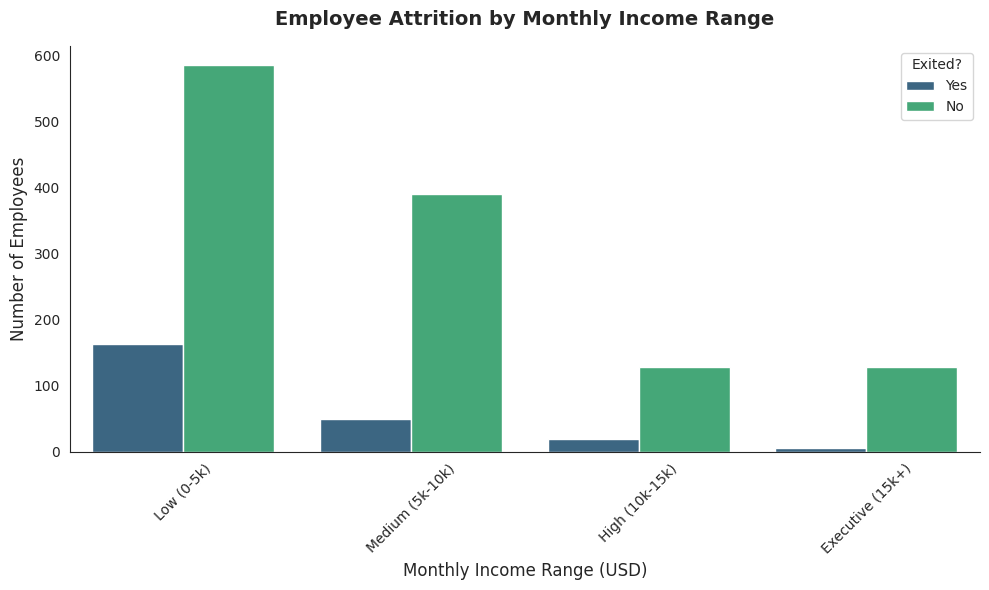

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("white")

sns.countplot(data=df, x="Income_Range", hue="Attrition", palette="viridis")

plt.title("Employee Attrition by Monthly Income Range", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Monthly Income Range (USD)", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.legend(title="Exited?")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

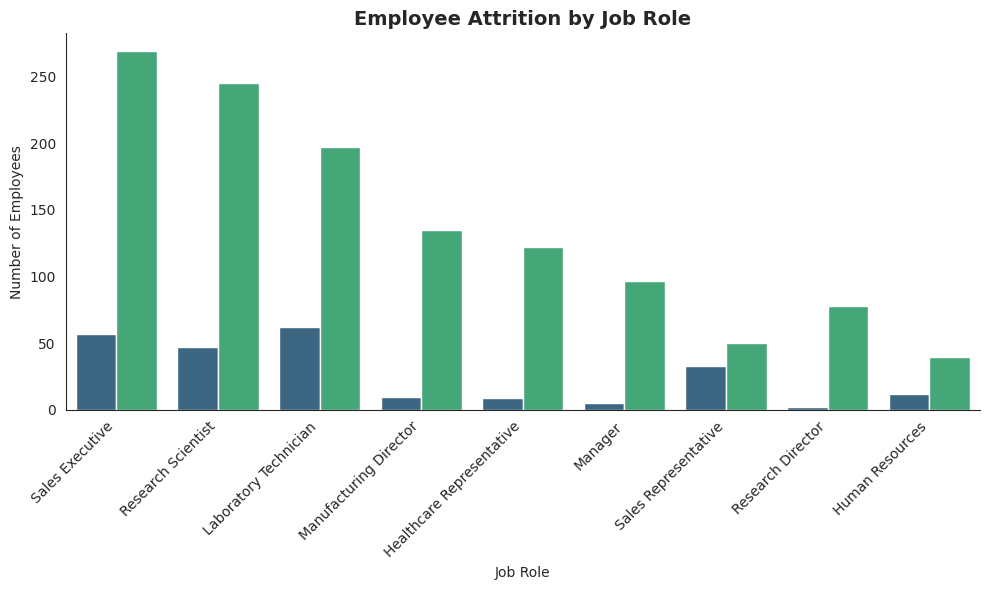

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("white")
sns.countplot(data=df, x="JobRole", hue="Attrition", palette="viridis", legend=False)
plt.title("Employee Attrition by Job Role", fontsize=14, fontweight='bold')
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

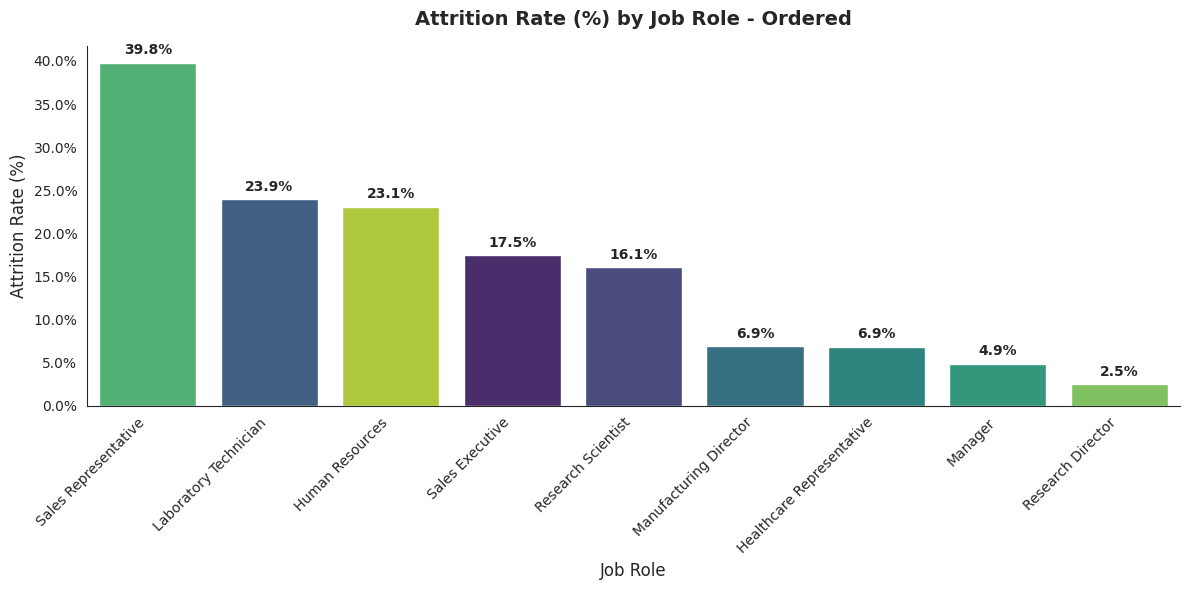

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mtick

df['Attrition_Rate'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
role_order = df.groupby('JobRole')['Attrition_Rate'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.set_style("white")

ax = sns.barplot(
    data=df,
    x="JobRole",
    y="Attrition_Rate",
    order=role_order,
    hue="JobRole",
    palette="viridis",
    errorbar=None
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


plt.title("Attrition Rate (%) by Job Role - Ordered", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Job Role", fontsize=12)
plt.ylabel("Attrition Rate (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1%}',
                       (p.get_x() + p.get_width() / 2., height),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points',
                       fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

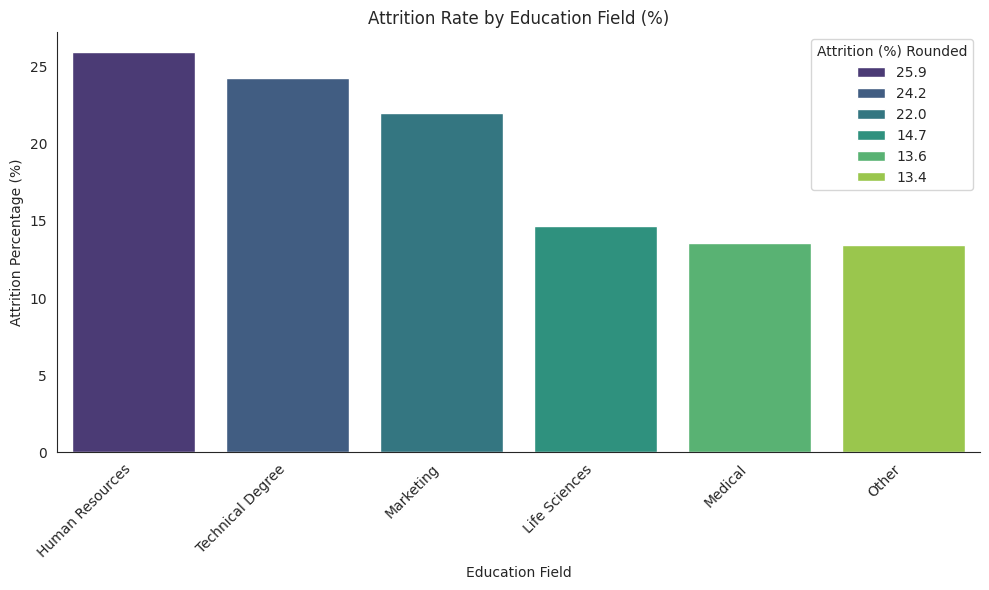

In [ ]:
df["Attrition.bin"] = df["Attrition"].map({"Yes": 1, "No": 0})
attrition_by_education = df.groupby("EducationField")["Attrition.bin"].value_counts(normalize=True).mul(100).unstack()
attrition_by_education = attrition_by_education.rename(columns={0: "No Attrition (%)", 1: "Attrition (%)"})
attrition_by_education = attrition_by_education.sort_values(by="Attrition (%)", ascending=False)
attrition_by_education["Attrition (%) Rounded"] = attrition_by_education["Attrition (%)"].round(1)
attrition_by_education["Attrition (%) Rounded"] = pd.Categorical(
    attrition_by_education["Attrition (%) Rounded"],
    categories=attrition_by_education["Attrition (%) Rounded"].sort_values(ascending=False).unique(),
    ordered=True
)
plt.figure(figsize=(10,6))
sns.barplot(x=attrition_by_education.index, y="Attrition (%)", data=attrition_by_education, palette="viridis", hue="Attrition (%) Rounded", legend=True)
plt.title("Attrition Rate by Education Field (%)")
plt.xlabel("Education Field")
plt.ylabel("Attrition Percentage (%)")
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

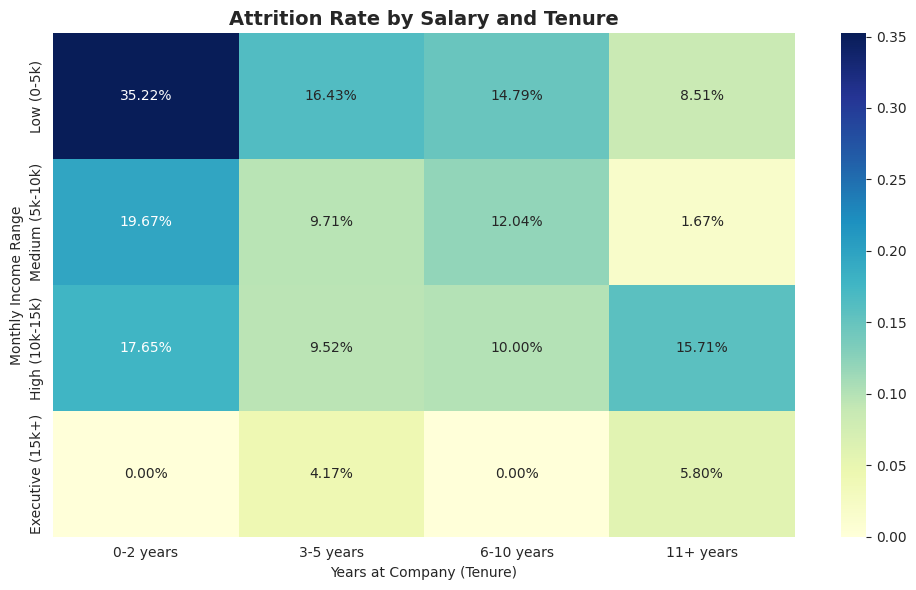

In [ ]:
df['Attrition_bin'] = df['Attrition'].map({'Yes': 1, 'No': 0})
pivot = df.pivot_table(
    index='Income_Range',
    columns='Tenure_Range',
    values='Attrition_bin',
    aggfunc='mean',
    observed=False
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="YlGnBu", cbar=True)

plt.title("Attrition Rate by Salary and Tenure", fontsize=14, fontweight='bold')
plt.xlabel("Years at Company (Tenure)")
plt.ylabel("Monthly Income Range")

plt.tight_layout()
plt.show()

The data reveals that the 'High-Risk' profile is a Sales Representative or Laboratory Technician, earning less than 5k/month, with less than 2 years of tenure, and frequently working overtime. This suggests that attrition in this company is driven by a lack of financial incentive and work-life balance for entry-level positions.

Analysis

In [ ]:
attrition_job = (df.groupby("JobRole")["Attrition_bin"].mean() * 100).round(2).reset_index()
attrition_job = attrition_job.sort_values("Attrition_bin", ascending=False)

attrition_job.columns = ['Job Role', 'Attrition Rate (%)']
attrition_job

,Job Role,Attrition Rate (%)
8,Sales Representative,39.76
2,Laboratory Technician,23.94
1,Human Resources,23.08
7,Sales Executive,17.48
6,Research Scientist,16.10
4,Manufacturing Director,6.90
0,Healthcare Representative,6.87
3,Manager,4.90
5,Research Director,2.50


In [ ]:
attrition_income = (df.groupby("Income_Range", observed=False)["Attrition_bin"].mean() * 100).round(2).reset_index()
attrition_income = attrition_income.sort_values("Attrition_bin", ascending=False)

attrition_income.columns = ['Income Range', 'Attrition Rate (%)']
attrition_income

,Income Range,Attrition Rate (%)
0,Low (0-5k),21.76
2,High (10k-15k),13.51
1,Medium (5k-10k),11.14
3,Executive (15k+),3.76


In [ ]:
attrition_tenure = (df.groupby("Tenure_Range", observed=False)["Attrition_bin"].mean() * 100).round(2).reset_index()
attrition_tenure = attrition_tenure.sort_values("Attrition_bin", ascending=False)

attrition_tenure.columns = ['Tenure Range', 'Attrition Rate (%)']
attrition_tenure

,Tenure Range,Attrition Rate (%)
0,0-2 years,29.82
1,3-5 years,13.82
2,6-10 years,12.28
3,11+ years,8.13


In [ ]:
attrition_education = (df.groupby("EducationField")["Attrition_bin"].mean() * 100).round(2).reset_index()
attrition_education = attrition_education.sort_values("Attrition_bin", ascending=False)

attrition_education.columns = ['Education Field', 'Attrition Rate (%)']
attrition_education

,Education Field,Attrition Rate (%)
0,Human Resources,25.93
5,Technical Degree,24.24
2,Marketing,22.01
1,Life Sciences,14.69
3,Medical,13.58
4,Other,13.41


Evaluation

In [ ]:
print(f"Job Role with highest attrition: {attrition_job.iloc[0]['Job Role']} ({attrition_job.iloc[0]['Attrition Rate (%)']}%)")
print(f"Income Range with highest attrition: {attrition_income.iloc[0]['Income Range']} ({attrition_income.iloc[0]['Attrition Rate (%)']}%)")
print(f"Tenure Range with highest attrition: {attrition_tenure.iloc[0]['Tenure Range']} ({attrition_tenure.iloc[0]['Attrition Rate (%)']}%)")
print(f"Education Field with highest attrition: {attrition_education.iloc[0]['Education Field']} ({attrition_education.iloc[0]['Attrition Rate (%)']}%)")

Job Role with highest attrition: Sales Representative (39.76%)
Income Range with highest attrition: Low (0-5k) (21.76%)
Tenure Range with highest attrition: 0-2 years (29.82%)
Education Field with highest attrition: Human Resources (25.93%)


Deploy

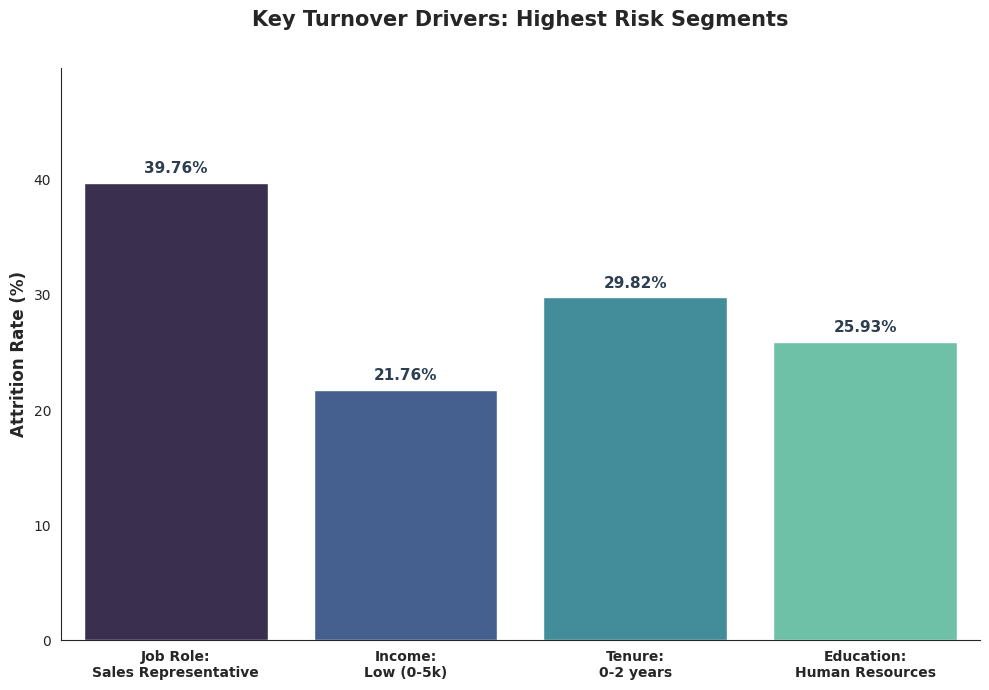

In [ ]:


categories = [
    f"Job Role:\n{attrition_job.iloc[0]['Job Role']}",
    f"Income:\n{attrition_income.iloc[0]['Income Range']}",
    f"Tenure:\n{attrition_tenure.iloc[0]['Tenure Range']}",
    f"Education:\n{attrition_education.iloc[0]['Education Field']}"
]

rates = [
    attrition_job.iloc[0]['Attrition Rate (%)'],
    attrition_income.iloc[0]['Attrition Rate (%)'],
    attrition_tenure.iloc[0]['Attrition Rate (%)'],
    attrition_education.iloc[0]['Attrition Rate (%)']
]

plt.figure(figsize=(10, 7))
sns.set_style("white")

ax = sns.barplot(x=categories, y=rates, hue=categories, palette="mako", legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold', color='#2c3e50')

plt.title("Key Turnover Drivers: Highest Risk Segments", fontsize=15, fontweight='bold', pad=30)
plt.ylabel("Attrition Rate (%)", fontsize=12, fontweight='bold')
plt.xlabel("")

plt.xticks(fontsize=10, fontweight='bold')

plt.ylim(0, max(rates) + 10)

sns.despine()
plt.tight_layout()
plt.savefig('attrition_summary_vertical.png', dpi=300)
plt.show()

Final Conclusion: HR Analytics Strategic Insights

Based on the data-driven analysis of the IBM Attrition Dataset, we can provide definitive answers to the project's core questions:

### 1. Who leaves the most? (The Attrition Profile)
The "High-Risk" profile is clearly identified as the **Sales Representative**. This role shows a staggering attrition rate of **39.76%**, nearly double the average of other departments. Employees with a **Technical Degree** and those working **Overtime** are also primary drivers of turnover.

### 2. Does income influence attrition?
**Yes, significantly.** There is a clear inverse correlation between salary and attrition. The **Low Income bracket (0-5k)** faces an attrition rate of **21.76%**, while employees earning over **15k (Executives)** almost never leave. Financial compensation is the strongest predictor of retention.

### 3. Does tenure matter?
**Yes, the first 24 months are critical.** Newcomers with **0-2 years** of tenure have a turnover rate of **29.82%**. Once an employee crosses the 5-year threshold, loyalty stabilizes.
